Инициализация Проекта

In [3]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 
import warnings

In [4]:
data = pd.read_csv("data/MathE_dataset.csv", sep=";",
    encoding="cp1252")

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9546 entries, 0 to 9545
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Student ID       9546 non-null   int64 
 1   Student Country  9546 non-null   object
 2   Question ID      9546 non-null   int64 
 3   Type of Answer   9546 non-null   int64 
 4   Question Level   9546 non-null   object
 5   Topic            9546 non-null   object
 6   Subtopic         9546 non-null   object
 7   Keywords         9546 non-null   object
dtypes: int64(3), object(5)
memory usage: 596.8+ KB


In [6]:
data.head(10)

,Student ID,Student Country,Question ID,Type of Answer,Question Level,Topic,Subtopic,Keywords
0,647,Ireland,77,0,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
1,41,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
2,340,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
3,641,Italy,77,0,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
4,669,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
5,697,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
6,720,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
7,675,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
8,663,Portugal,77,0,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
9,28,Portugal,77,0,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."


<font size=4><b>Получили следующую характеристику исходных данных:</b>

датасет содержит 9546 наблюдений и 8 признаков

во всех столбцах отсутствуют пропущенные значения

числовые признаки представлены столбцами Student ID, Question ID, Type of Answer

категориальные признаки представлены столбцами Student Country, Question Level, Topic, Subtopic, Keywords

Question level, Topic, Subtopic и Keywords колонки которые стоит разделить на множество других, и представить это численно

столбец Type of Answer, отражает корректность ответа (0 — неверный, 1 — верный).</font>

<font size=4><b>Столбцы с неподходящими типами данных:</b>

столбец Keywords должен быть преобразован в список значений.</font>

<font size=4><b>Краткое описание пропущенных значений во всех столбцах:</b>

пропущенные значения в датасете отсутствуют, дополнительная обработка NaN не требуется.</font>

In [7]:
data.describe()

,Student ID,Question ID,Type of Answer
count,9546.000000,9546.000000,9546.000000
mean,775.402263,478.912319,0.468259
std,460.590559,249.244061,0.499018
min,26.000000,77.000000,0.000000
25%,380.000000,323.000000,0.000000
50%,885.000000,428.000000,0.000000
75%,1219.000000,571.000000,1.000000
max,1565.000000,1549.000000,1.000000


Выводы которые можно сделать по данному датафрейму это только что больше половины ответов были неправильными

В остальном сырой decribe для нас бесполезен

Проверим на пустые значения

In [8]:
(data.isna().sum()/data.shape[0]*100).sort_values(ascending=False)

Student ID         0.0
Student Country    0.0
Question ID        0.0
Type of Answer     0.0
Question Level     0.0
Topic              0.0
Subtopic           0.0
Keywords           0.0
dtype: float64

Пустых значений нет

Перейдём на этап обогащения данных, сейчас преобазуем данные: 

колонку сложности вопроса разобъем на две колонки 


In [9]:
data["Question Level"].value_counts()

Question Level
Basic       7844
Advanced    1702
Name: count, dtype: int64

In [10]:
level_dummies = pd.get_dummies(
    data["Question Level"],
    prefix="level"
).astype(int)

In [11]:
data = data.loc[:, ~data.columns.str.startswith("level_")]

In [12]:
data = pd.concat([data, level_dummies], axis=1)

In [13]:
data[["Question Level", "level_Basic", "level_Advanced"]].head(87)

,Question Level,level_Basic,level_Advanced
0,Basic,1,0
1,Basic,1,0
2,Basic,1,0
3,Basic,1,0
4,Basic,1,0
...,...,...,...
82,Basic,1,0
83,Basic,1,0
84,Basic,1,0
85,Advanced,0,1


Можем теперь избавиться от старой колнки

In [14]:
data = data.drop(columns=["Question Level"])

In [15]:
data.head()

,Student ID,Student Country,Question ID,Type of Answer,Topic,Subtopic,Keywords,level_Advanced,level_Basic
0,647,Ireland,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1
1,41,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1
2,340,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1
3,641,Italy,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1
4,669,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1


Аналогичные действия проделаем с topic и subtopic

In [16]:
data["Topic"].value_counts()

Topic
Linear Algebra                         5726
Fundamental Mathematics                 818
Complex Numbers                         592
Differentiation                         579
Analytic Geometry                       358
Statistics                              340
Numerical Methods                       310
Optimization                            182
Real Functions of a single variable     164
Integration                             144
Probability                             128
Differential Equations                  108
Graph Theory                             55
Set Theory                               42
Name: count, dtype: int64

In [17]:
data["Subtopic"].value_counts()


Subtopic
Vector Spaces                                         2749
Linear Transformations                                2127
Complex Numbers                                        592
Algebraic expressions, Equations, and Inequalities     496
Linear Systems                                         420
Analytic Geometry                                      358
Statistics                                             340
Elementary Geometry                                    322
Derivatives                                            317
Numerical Methods                                      310
Matrices and Determinants                              300
Partial Differentiation                                262
Eigenvalues and Eigenvectors                           130
Probability                                            128
Nonlinear Optimization                                 126
Integration Techniques                                 111
Differential Equations                         

После анализа информации по этим колонкам принимаю решение отказаться от дальнейшего использования колoнки Topic для разбиения и оставить только для составления различной статистики и визуализации, колонку Subtopic надо доработать так как имеются чрезвычайно редкие подтемы, и пограничные

Double Integration и Definite Integrals можно объединить с Integration Techniques 

Set Theory объединим с Algebraic expressions, Equations, and Inequalities

Limits and Continuity с Real Functions of a single variable

Linear Optimization с Nonlinear Optimization объединим в колонку Optimization

Graph Theory придётся оставить, всё же там не одна строка пожтому как будто не сильно критично

In [18]:
subtopic_for_encoding = data["Subtopic"].copy()

subtopic_mapping = {
    "Double Integration": "Integration",
    "Definite Integrals": "Integration",
    "Set Theory": "Algebraic expressions, Equations, and Inequalities",
    "Limits and Continuity": "Differentiation",
    "Linear Optimization": "Optimization"
}

subtopic_for_encoding = subtopic_for_encoding.replace(subtopic_mapping)

In [19]:
subtopic_dummies = pd.get_dummies(
    subtopic_for_encoding,
    prefix="subtopic"
).astype(int)

In [20]:
data = pd.concat([data, subtopic_dummies], axis=1)

In [21]:
data.head(10)

,Student ID,Student Country,Question ID,Type of Answer,Topic,Subtopic,Keywords,level_Advanced,level_Basic,"subtopic_Algebraic expressions, Equations, and Inequalities",...,subtopic_Linear Systems,subtopic_Linear Transformations,subtopic_Matrices and Determinants,subtopic_Nonlinear Optimization,subtopic_Numerical Methods,subtopic_Optimization,subtopic_Partial Differentiation,subtopic_Probability,subtopic_Statistics,subtopic_Vector Spaces
0,647,Ireland,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,1,0
1,41,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,1,0
2,340,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,1,0
3,641,Italy,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,1,0
4,669,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,1,0
5,697,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,1,0
6,720,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,1,0
7,675,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,1,0
8,663,Portugal,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,1,0
9,28,Portugal,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,1,0


Теперь надо разобраться с Keywords, для начала проанализируем вообще сами ключевые слоова

In [22]:
data["Keywords"].value_counts()

Keywords
Linear application,Linearity                                                                           443
Simplify expressions                                                                                   401
Subspace,Linear combination,Span                                                                       401
Linear independence,Span,Linear dependence                                                             399
Range,Kernel                                                                                           344
                                                                                                      ... 
Fundamental theorem of Calculus,Partial fractions decomposition                                          1
Minimum,Maximum,Lagrange multipliers,Saddle point,Unconstrained optimization,Second derivative test      1
Quadratic equations,Simplify expressions,Linear equations                                                1
Linear equations,Quadratic e

In [23]:
keywords_list = data["Keywords"].str.split(",").apply(lambda lst: [kw.strip() for kw in lst])

In [24]:
from collections import Counter

all_keywords = [kw for sublist in keywords_list for kw in sublist]

keyword_counts = Counter(all_keywords)

In [25]:
keyword_counts_series = pd.Series(keyword_counts).sort_values(ascending=False)

In [26]:
keyword_counts_series.tail(45)

Rhombus                             17
Cartesian coordinates               16
Adjacency matrix                    16
Fundamental theorem of Calculus     15
Linear regression                   15
Tree                                14
Cauchy problem                      14
Image of a function                 14
Spanning tree                       14
Homogeneous equation                14
Shortest path                       12
Polyhedrons                         12
Trigonometric substitution          12
Iterate integrals                   12
y-simple region (type I)            11
Conditional probability              8
Rational functions                   8
Power of trigonometric functions     7
Chromatic number                     7
Chi square distribution              7
Bayes' Theorem                       7
Area                                 7
Cycle and circuit                    6
Chain rule                           5
Integral curve                       5
Sensitivity analysis     

те темы которые появляются меньше 10 раз просто не будем учитывать в нашем разбиении, и теперь создаём такую же бинарную структуру как и в предыдущих колонках, где создастся порядка 130 колонок и единица в соответствующей колонке будет означать наличие данного ключевого слова в теме, а ноль его отсутствие 

In [27]:
frequent_keywords = set([k for k, v in keyword_counts.items() if v > 10])

keywords_filtered = keywords_list.apply(lambda lst: [kw for kw in lst if kw in frequent_keywords])

In [28]:
keywords_dummies = pd.DataFrame(0, index=data.index, columns=sorted(frequent_keywords))

for idx, words in keywords_filtered.items():
    keywords_dummies.loc[idx, words] = 1

In [29]:
data = pd.concat([data, keywords_dummies], axis=1)

In [30]:
data.head(10)

,Student ID,Student Country,Question ID,Type of Answer,Topic,Subtopic,Keywords,level_Advanced,level_Basic,"subtopic_Algebraic expressions, Equations, and Inequalities",...,Triangles,Trigonometric form,Trigonometric rules,Trigonometric substitution,Unconstrained optimization,Undetermined solution of linear system,Variance,and total probability rules,multiplication,y-simple region (type I)
0,647,Ireland,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,41,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,340,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,641,Italy,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,669,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
5,697,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
6,720,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
7,675,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
8,663,Portugal,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
9,28,Portugal,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9546 entries, 0 to 9545
Columns: 194 entries, Student ID to y-simple region (type I)
dtypes: int64(190), object(4)
memory usage: 14.1+ MB


In [33]:
data[data.duplicated(keep=False)].head(10)

,Student ID,Student Country,Question ID,Type of Answer,Topic,Subtopic,Keywords,level_Advanced,level_Basic,"subtopic_Algebraic expressions, Equations, and Inequalities",...,Triangles,Trigonometric form,Trigonometric rules,Trigonometric substitution,Unconstrained optimization,Undetermined solution of linear system,Variance,and total probability rules,multiplication,y-simple region (type I)
28,41,Portugal,79,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
29,41,Portugal,79,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
35,57,Portugal,79,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
36,57,Portugal,79,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
78,181,Italy,83,0,Real Functions of a single variable,"Domain, Image and Graphics","Domain,Image of a function",0,1,0,...,0,0,0,0,0,0,0,0,0,0
79,181,Italy,83,0,Real Functions of a single variable,"Domain, Image and Graphics","Domain,Image of a function",0,1,0,...,0,0,0,0,0,0,0,0,0,0
88,1557,Portugal,87,0,Real Functions of a single variable,Limits and Continuity,"Indeterminate forms,Limits",1,0,0,...,0,0,0,0,0,0,0,0,0,0
89,1557,Portugal,87,0,Real Functions of a single variable,Limits and Continuity,"Indeterminate forms,Limits",1,0,0,...,0,0,0,0,0,0,0,0,0,0
90,854,Italy,88,1,Linear Algebra,Linear Systems,"Inconsistent system,Square linear system,Solut...",0,1,0,...,0,0,0,0,0,1,0,0,0,0
91,854,Italy,88,1,Linear Algebra,Linear Systems,"Inconsistent system,Square linear system,Solut...",0,1,0,...,0,0,0,0,0,1,0,0,0,0


In [34]:
data = data.drop_duplicates()

In [35]:
data.duplicated().sum()

np.int64(0)

In [36]:
data.head(10)

,Student ID,Student Country,Question ID,Type of Answer,Topic,Subtopic,Keywords,level_Advanced,level_Basic,"subtopic_Algebraic expressions, Equations, and Inequalities",...,Triangles,Trigonometric form,Trigonometric rules,Trigonometric substitution,Unconstrained optimization,Undetermined solution of linear system,Variance,and total probability rules,multiplication,y-simple region (type I)
0,647,Ireland,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,41,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,340,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,641,Italy,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,669,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
5,697,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
6,720,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
7,675,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
8,663,Portugal,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0
9,28,Portugal,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,0


В целом, данные выглядят чистыми и готовы к EDA

Ключевая переменная - Type of Answer 

Student ID - бесполезный признак, просто служебный
Уровень вопроса - ключевой признак
Topic - не самый полезный
Subtopic - важный признак
Keywords - важные признаки
Country - требует дальнейшего исследования, мне кажется чуть более ключевой чем ID, но всё равно не очень важен



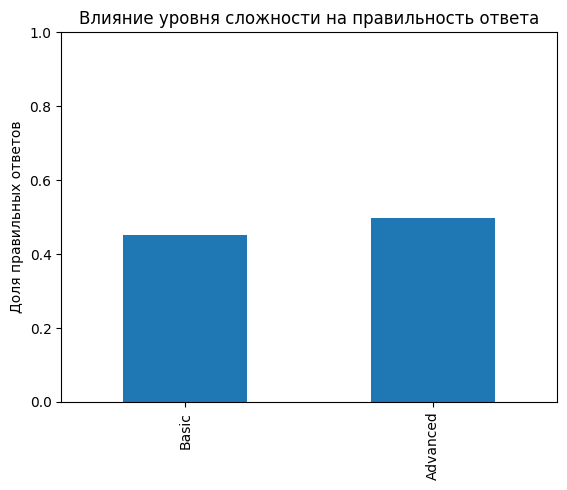

In [42]:
accuracy_by_level = pd.Series({
    "Basic": basic_accuracy,
    "Advanced": advanced_accuracy
})

accuracy_by_level.plot(kind="bar")
plt.ylabel("Доля правильных ответов")
plt.title("Влияние уровня сложности на правильность ответа")
plt.ylim(0, 1)
plt.show()

Вопреки ожиданиям, уровень вопрорса не является ключевым, а так как сложных вопросов значительно меньше, чем базовых, то можно сделать вывод, что более сложные вопросы решают более мотивированные ученики

In [ ]:
subtopic_stats = (
    data
    .groupby("Subtopic")["Type of Answer"]
    .agg(
        count="count",
        accuracy="mean"
    )
    .sort_values("accuracy", ascending=False)
)


In [46]:
subtopic_stats

,count,accuracy
Subtopic,,
Definite Integrals,15,0.733333
Set Theory,40,0.650000
Eigenvalues and Eigenvectors,125,0.568000
Graph Theory,53,0.566038
Linear Systems,360,0.563889
Double Integration,16,0.562500
Differential Equations,103,0.533981
Elementary Geometry,244,0.524590
Matrices and Determinants,274,0.510949


<Axes: xlabel='Subtopic'>

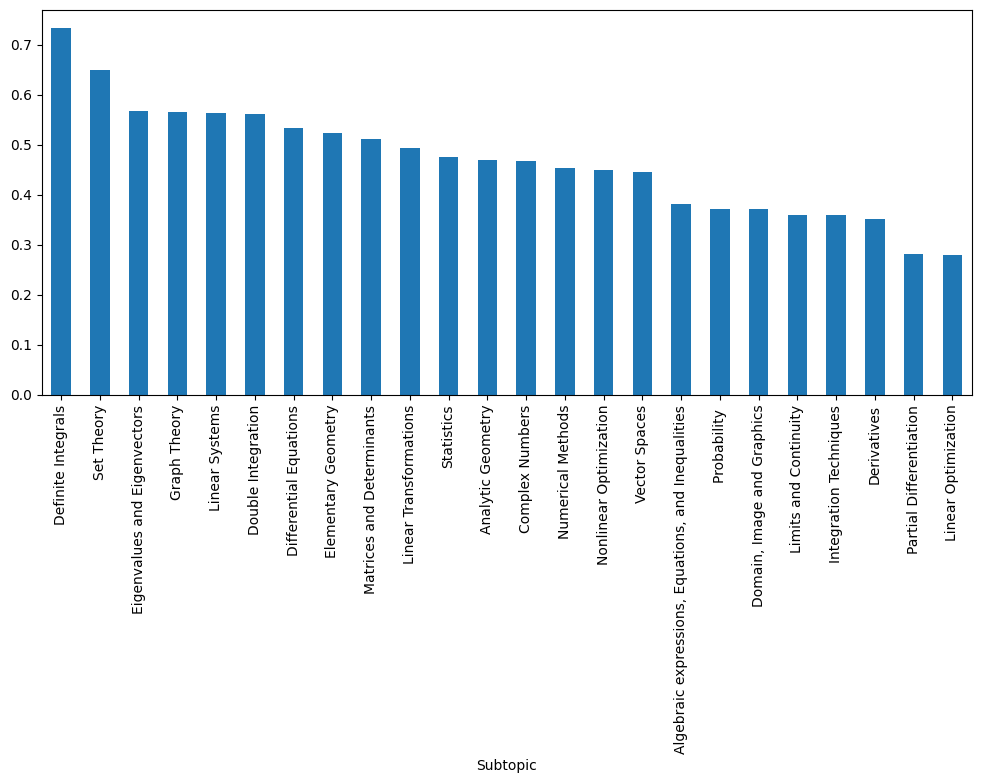

In [45]:
subtopic_stats["accuracy"].plot(kind="bar", figsize=(12, 5))

In [47]:
subtopic_mapping = {
    "Double Integration": "Integration Techniques",
    "Definite Integrals": "Integration Techniques",

    "Set Theory": "Algebraic expressions, Equations, and Inequalities",

    "Limits and Continuity": "Real Functions of a single variable",

    "Linear Optimization": "Optimization",
    "Nonlinear Optimization": "Optimization"
}

In [49]:
data_merged = data.copy()

data_merged["Subtopic_merged"] = (
    data_merged["Subtopic"]
    .replace(subtopic_mapping)
)


In [50]:
data_merged["Subtopic_merged"].value_counts()


Subtopic_merged
Vector Spaces                                         1860
Linear Transformations                                1522
Complex Numbers                                        512
Algebraic expressions, Equations, and Inequalities     454
Linear Systems                                         360
Statistics                                             330
Analytic Geometry                                      304
Derivatives                                            298
Matrices and Determinants                              274
Elementary Geometry                                    244
Numerical Methods                                      236
Partial Differentiation                                230
Optimization                                           161
Integration Techniques                                 134
Eigenvalues and Eigenvectors                           125
Probability                                            124
Differential Equations                  

<Axes: xlabel='Subtopic_merged'>

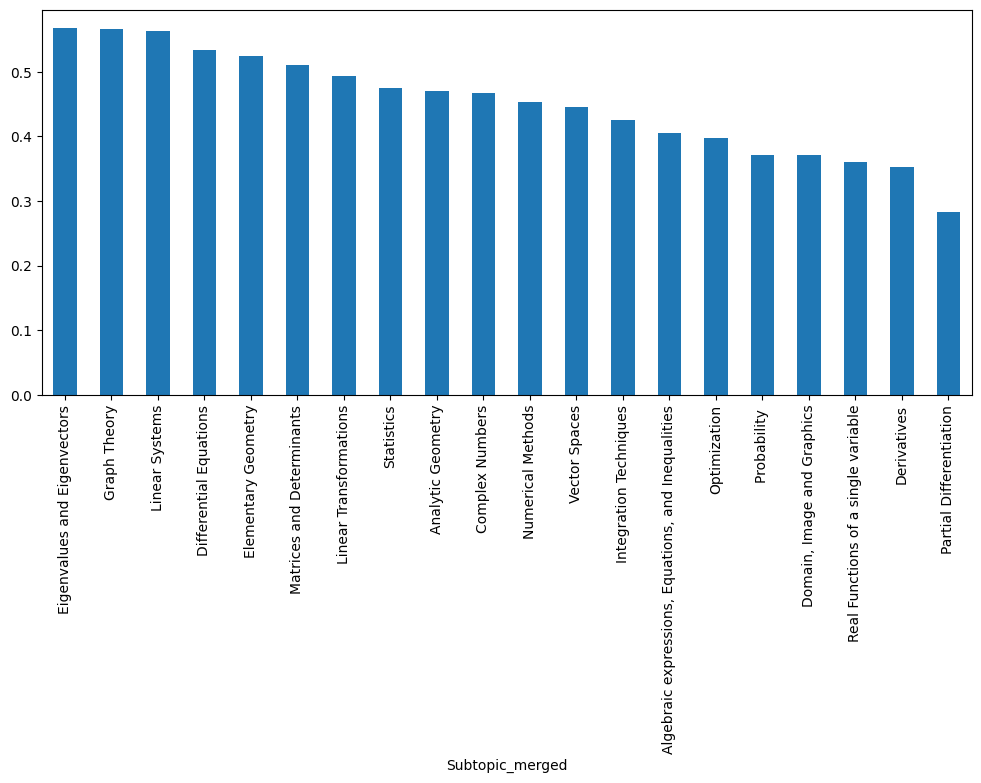

In [52]:
subtopic_stats_merged = (
    data_merged
    .groupby("Subtopic_merged")["Type of Answer"]
    .agg(
        count="count",
        accuracy="mean"
    )
    .sort_values("accuracy", ascending=False)
)
subtopic_stats_merged["accuracy"].plot(kind="bar", figsize=(12, 5))

In [53]:
subtopic_stats_merged

,count,accuracy
Subtopic_merged,,
Eigenvalues and Eigenvectors,125,0.568000
Graph Theory,53,0.566038
Linear Systems,360,0.563889
Differential Equations,103,0.533981
Elementary Geometry,244,0.524590
Matrices and Determinants,274,0.510949
Linear Transformations,1522,0.493430
Statistics,330,0.475758
Analytic Geometry,304,0.470395


В целом можно выделить те темы которые сдают лучше в среднем, средний результат и слабые темы

In [54]:
data_merged.head()

,Student ID,Student Country,Question ID,Type of Answer,Topic,Subtopic,Keywords,level_Advanced,level_Basic,"subtopic_Algebraic expressions, Equations, and Inequalities",...,Trigonometric form,Trigonometric rules,Trigonometric substitution,Unconstrained optimization,Undetermined solution of linear system,Variance,and total probability rules,multiplication,y-simple region (type I),Subtopic_merged
0,647,Ireland,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,Statistics
1,41,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,Statistics
2,340,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,Statistics
3,641,Italy,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,Statistics
4,669,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,0,Statistics


In [56]:
non_keyword_cols = {
    "Student ID",
    "Student Country",
    "Question ID",
    "Type of Answer",
    "Topic",
    "Subtopic",
    "Keywords",
    "Subtopic_merged"
}

keyword_cols = [c for c in data.columns if c not in non_keyword_cols 
                and not c.startswith("level_")
                and not c.startswith("subtopic_")]

keyword_stats = []

for kw in keyword_cols:
    subset = data[data[kw] == 1]
    
    keyword_stats.append({
        "keyword": kw,
        "count": len(subset),
        "accuracy": subset["Type of Answer"].mean()
    })

keyword_stats_df = (
    pd.DataFrame(keyword_stats)
    .dropna()
    .sort_values("count", ascending=False)
)

In [59]:
keyword_stats_df

,keyword,count,accuracy
136,Span,1255,0.435857
146,Subspace,1010,0.468317
69,Linear combination,853,0.460727
4,Basis,738,0.437669
68,Linear application,581,0.488812
...,...,...,...
120,Rhombus,12,0.416667
63,Iterate integrals,11,0.454545
156,Trigonometric substitution,11,0.181818
162,y-simple region (type I),10,0.400000


In [60]:
keyword_stats_filtered = keyword_stats_df[
    keyword_stats_df["count"] > 10
]

keyword_stats_filtered

,keyword,count,accuracy
136,Span,1255,0.435857
146,Subspace,1010,0.468317
69,Linear combination,853,0.460727
4,Basis,738,0.437669
68,Linear application,581,0.488812
...,...,...,...
51,Image of a function,13,0.461538
129,Shortest path,12,0.500000
120,Rhombus,12,0.416667
63,Iterate integrals,11,0.454545


In [61]:
keyword_stats_filtered.head(10)

,keyword,count,accuracy
136,Span,1255,0.435857
146,Subspace,1010,0.468317
69,Linear combination,853,0.460727
4,Basis,738,0.437669
68,Linear application,581,0.488812
75,Linearity,513,0.487329
116,Range,509,0.520629
64,Kernel,509,0.520629
27,Dimension,419,0.458234
133,Simplify expressions,414,0.381643


In [66]:
keyword_stats_filtered.sort_values("accuracy", ascending=False).head(10)

,keyword,count,accuracy
49,Homogeneous equation,13,0.769231
45,Geometric transformations,20,0.750000
11,Classification of geometric solids,19,0.736842
43,Fundamental theorem of Calculus,15,0.733333
26,Diagonalization,41,0.731707
65,Lagrange multipliers,18,0.666667
74,Linear regression,15,0.666667
145,Subset,34,0.647059
44,Geometric solids,28,0.642857
130,Simple graph,22,0.636364


In [65]:
keyword_stats_filtered.sort_values("accuracy").head(10)

,keyword,count,accuracy
38,Excel solver add-in,17,0.176471
156,Trigonometric substitution,11,0.181818
40,Exponential rule,34,0.205882
29,Directional derivative,29,0.206897
73,Linear programming,52,0.250000
47,Gradient,66,0.272727
104,Point estimate,18,0.277778
17,Confidence interval,18,0.277778
32,Duality theory,17,0.294118
152,Triangle inequality,16,0.312500


В целом, не могу сказать что есть значительные выбросы в данном датасете 

Также можем выделить сложные/простые темы

In [67]:
data_level = data_merged.copy()

data_level["level"] = data_level["level_Advanced"]


In [70]:
data_level.head()

,Student ID,Student Country,Question ID,Type of Answer,Topic,Subtopic,Keywords,level_Advanced,level_Basic,"subtopic_Algebraic expressions, Equations, and Inequalities",...,Trigonometric rules,Trigonometric substitution,Unconstrained optimization,Undetermined solution of linear system,Variance,and total probability rules,multiplication,y-simple region (type I),Subtopic_merged,level
0,647,Ireland,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,Statistics,0
1,41,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,Statistics,0
2,340,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,Statistics,0
3,641,Italy,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,Statistics,0
4,669,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,1,0,...,0,0,0,0,0,0,0,0,Statistics,0


In [71]:
data_level = data_level.drop(columns=["level_Basic", "level_Advanced"])

In [73]:
data_level.head(100)

,Student ID,Student Country,Question ID,Type of Answer,Topic,Subtopic,Keywords,"subtopic_Algebraic expressions, Equations, and Inequalities",subtopic_Analytic Geometry,subtopic_Complex Numbers,...,Trigonometric rules,Trigonometric substitution,Unconstrained optimization,Undetermined solution of linear system,Variance,and total probability rules,multiplication,y-simple region (type I),Subtopic_merged,level
0,647,Ireland,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,0,0,...,0,0,0,0,0,0,0,0,Statistics,0
1,41,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,0,0,...,0,0,0,0,0,0,0,0,Statistics,0
2,340,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,0,0,...,0,0,0,0,0,0,0,0,Statistics,0
3,641,Italy,77,0,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,0,0,...,0,0,0,0,0,0,0,0,Statistics,0
4,669,Portugal,77,1,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl...",0,0,0,...,0,0,0,0,0,0,0,0,Statistics,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,854,Italy,89,0,Linear Algebra,Linear Systems,"Square linear system,Inconsistent system,Solut...",0,0,0,...,0,0,0,1,0,0,0,0,Linear Systems,0
102,860,Italy,89,1,Linear Algebra,Linear Systems,"Square linear system,Inconsistent system,Solut...",0,0,0,...,0,0,0,1,0,0,0,0,Linear Systems,0
103,510,Portugal,89,0,Linear Algebra,Linear Systems,"Square linear system,Inconsistent system,Solut...",0,0,0,...,0,0,0,1,0,0,0,0,Linear Systems,0
104,979,Portugal,89,0,Linear Algebra,Linear Systems,"Square linear system,Inconsistent system,Solut...",0,0,0,...,0,0,0,1,0,0,0,0,Linear Systems,0


Общий вывод по проекту

Данный проект направлен на исследование образовательного датасета, содержащего информацию об ответах студентов на математические задания различной тематики и уровня сложности. Целью анализа являлось выявление факторов, влияющих на корректность ответа, а также подготовка данных для последующего моделирования.

В начале работы были загружены необходимые библиотеки, выполнен первичный анализ структуры данных, изучены примеры строк и сводная информация о признаках. В ходе анализа были выявлены особенности структуры датасета, связанные с категориальными признаками и многозначными ключевыми словами.

Обработка пропущенных значений

В датасете отсутствуют пропущенные значения во всех столбцах, что исключает необходимость их заполнения или удаления строк. Это позволяет использовать все наблюдения в дальнейшем анализе без потери информации.

Приведение и оптимизация структуры данных

Категориальные признаки Topic и Subtopic были проанализированы на предмет частотности и смысловой нагрузки. Для уменьшения размерности и повышения интерпретируемости данных ряд редко встречающихся подтем был объединён с семантически близкими разделами, в результате чего был сформирован признак Subtopic_merged.

Признак Keywords, содержащий перечень ключевых понятий задания, был преобразован в набор бинарных признаков (multi-hot encoding). Для снижения шума и размерности были исключены ключевые слова, встречающиеся менее чем в 10 наблюдениях.

Проверка дублирующихся данных

В ходе анализа были обнаружены полностью дублирующиеся строки. Такие наблюдения не несут дополнительной информации и могут искажать статистические оценки, поэтому их удаление является обоснованным и корректным шагом предобработки.

Анализ выбросов

В датасете отсутствуют непрерывные числовые признаки, для которых применим классический анализ выбросов (например, на основе IQR или boxplot). Однако были выявлены структурные выбросы, связанные с отдельными заданиями, подтемами и ключевыми словами, демонстрирующими аномально высокую или низкую долю правильных ответов. Такие случаи были отмечены и учтены при интерпретации результатов.

Исследование факторов, влияющих на корректность ответа

В рамках разведочного анализа данных были изучены зависимости между корректностью ответа и основными признаками:

Уровень сложности задания

Продвинутые задания оказались решены лучше чем базовые, поэтому можно сделать вывод, что продвинутые решают те кто готовы их решать.

Подтемы заданий

Анализ показал значительную вариативность сложности между различными подтемами. Наиболее сложными оказались разделы, связанные с дифференциальным исчислением и анализом функций, тогда как задания по линейной алгебре и линейным системам характеризуются более высокой долей правильных ответов.

Ключевые слова

Анализ ключевых понятий задания выявил, что отдельные математические концепции существенно различаются по сложности. Ключевые слова, связанные с частными производными, вероятностью и анализом функций, демонстрируют низкую точность ответов, тогда как линейные и алгебраические концепции оказываются более доступными для студентов.

Итог

В результате работы была выполнена полная предобработка датасета, проведён качественный разведочный анализ данных и выявлены ключевые факторы, влияющие на корректность ответов студентов. Полученные результаты могут быть использованы для построения моделей машинного обучения, анализа сложности учебных заданий и оптимизации образовательного контента.